In [25]:
import pandas as pd
from datetime import date
import matplotlib.pyplot as plt
import numpy as np


df_players = pd.read_csv("Base_Cadastral_de_Players.csv", sep=";")
df_transacoes = pd.read_csv("Base_de_Transacoes_e_Cupons_Capturados.csv", sep=";")
df_lojas = pd.read_csv("Base_Massa_de_Teste_com_Lojas_e_Valores.csv", sep=";")
df_simulacao = pd.read_csv("Base_Simulada_-_Pedestres_Av__Paulista.csv", sep=";")

In [26]:
def resumo(df):
    return pd.DataFrame({
        "dtype": df.dtypes,
        "na": df.isna().sum(),
        "% preenchido": (df.notna().mean()*100).round(2),
        "n_distintos": df.nunique()
    })


In [27]:
df_filtrado = df_simulacao[df_simulacao["possui_app_picmoney"] == "Sim"]

resumo(df_filtrado)

,dtype,na,% preenchido,n_distintos
celular,object,0,100.0,59939
data,object,0,100.0,1
horario,object,0,100.0,65
local,object,0,100.0,10
latitude,object,0,100.0,59957
longitude,object,0,100.0,59957
tipo_celular,object,0,100.0,2
modelo_celular,object,0,100.0,10
possui_app_picmoney,object,0,100.0,1
data_ultima_compra,object,0,100.0,30


In [28]:
lojas_trans = set(df_transacoes["nome_estabelecimento"].unique())
lojas_base  = set(df_lojas["nome_loja"].unique())

lojas_comuns = lojas_trans & lojas_base 
print(len(lojas_trans), len(lojas_base), len(lojas_comuns))


33 15 7


In [29]:
print(resumo(df_players))

                        dtype    na  % preenchido  n_distintos
celular                object     0        100.00         9999
data_nascimento        object     0        100.00         8346
idade                   int64     0        100.00           76
sexo                   object     0        100.00            3
cidade_residencial     object     0        100.00          530
bairro_residencial     object     0        100.00           21
cidade_trabalho        object  3969         60.31            1
bairro_trabalho        object  3969         60.31           21
cidade_escola          object  6932         30.68            1
bairro_escola          object  6932         30.68           21
categoria_frequentada  object     0        100.00           29


In [30]:
print(resumo(df_transacoes))

                             dtype     na  % preenchido  n_distintos
celular                     object      0        100.00         4813
data                        object      0        100.00           31
hora                        object      0        100.00           65
nome_estabelecimento        object      0        100.00           33
bairro_estabelecimento      object      0        100.00           21
categoria_estabelecimento   object      0        100.00           29
id_campanha                 object      0        100.00         9000
id_cupom                    object      0        100.00        94680
tipo_cupom                  object      0        100.00            3
produto                     object  66672         33.33          182
valor_cupom                float64      0        100.00        60201
repasse_picmoney           float64      0        100.00        24041


In [31]:
print(resumo(df_lojas))

                  dtype  na  % preenchido  n_distintos
numero_celular   object   0         100.0         9999
data_captura     object   0         100.0           31
tipo_cupom       object   0         100.0            3
tipo_loja        object   0         100.0            8
local_captura    object   0         100.0            7
latitude         object   0         100.0        10000
longitude        object   0         100.0        10000
nome_loja        object   0         100.0           15
endereco_loja    object   0         100.0           14
valor_compra    float64   0         100.0         9498
valor_cupom     float64   0         100.0         6503


In [32]:
print(resumo(df_simulacao))

                          dtype     na  % preenchido  n_distintos
celular                  object      0        100.00        99935
data                     object      0        100.00            1
horario                  object      0        100.00           65
local                    object      0        100.00           10
latitude                 object      0        100.00       100000
longitude                object      0        100.00       100000
tipo_celular             object      0        100.00            2
modelo_celular           object      0        100.00           10
possui_app_picmoney      object      0        100.00            2
data_ultima_compra       object  40043         59.96           30
ultimo_tipo_cupom        object  40043         59.96            3
ultimo_valor_capturado  float64  40043         59.96        34527
ultimo_tipo_loja         object  40043         59.96            8
idade                     int64      0        100.00           55
sexo      

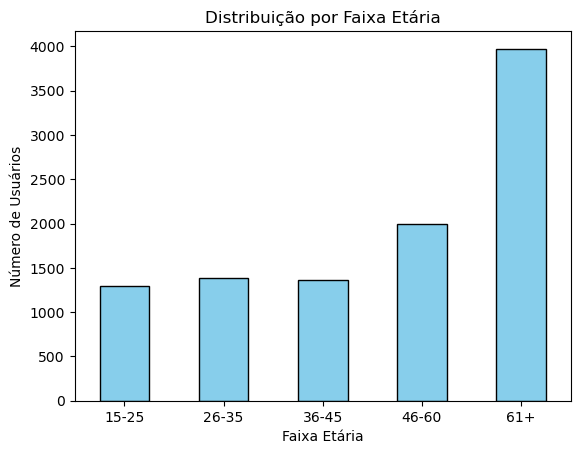

In [33]:

df_players["data_nascimento"] = pd.to_datetime(df_players["data_nascimento"], format="%d/%m/%Y", errors="coerce")
hoje = pd.to_datetime(date.today())

df_players["idade"] = (
    hoje.year - df_players["data_nascimento"].dt.year
    - ((hoje.month < df_players["data_nascimento"].dt.month) |
       ((hoje.month == df_players["data_nascimento"].dt.month) &
        (hoje.day < df_players["data_nascimento"].dt.day)))
)

media_idade = df_players["idade"].mean()
maior_idade = df_players["idade"].max()
menor_idade = df_players["idade"].min()

bins = [15, 25, 35, 45, 60, 100]  
labels = ["15-25", "26-35", "36-45", "46-60", "61+"]

df_players["faixa_etaria"] = pd.cut(df_players["idade"], bins=bins, labels=labels, right=True)

faixa_counts = df_players["faixa_etaria"].value_counts().sort_index()

faixa_counts.plot(kind="bar", edgecolor="black", color="skyblue")
plt.title("Distribuição por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Número de Usuários")
plt.xticks(rotation=0)
plt.show()


In [39]:
col1 = "valor_cupom"
col2 = "repasse_picmoney"

x = to_num_col(df_transacoes[col1])
y = to_num_col(df_transacoes[col2])

r = x.corr(y, method="pearson")
print(f"Correlação entre {col1} e {col2}: {r:.4f}")


Correlação entre valor_cupom e repasse_picmoney: 0.3690


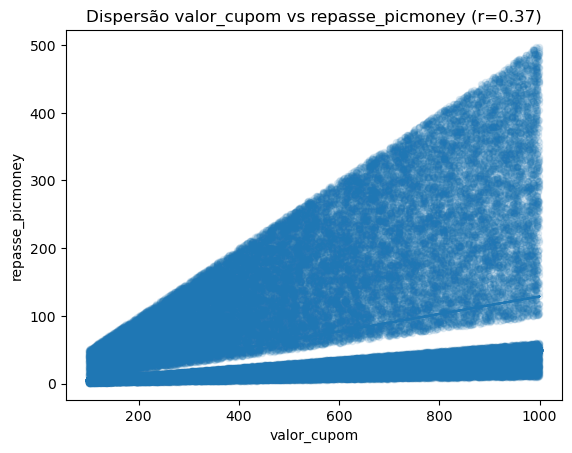

In [40]:
mask = x.notna() & y.notna()
xv, yv = x[mask], y[mask]

plt.scatter(xv, yv, alpha=0.1, s=20)

m, b = np.polyfit(xv, yv, 1)
plt.plot(xv, m*xv + b)

plt.xlabel(col1); plt.ylabel(col2)
plt.title(f"Dispersão {col1} vs {col2} (r={r:.2f})")
plt.show()